# 010 — Binary Portfolio Optimization via QUBO v 1.2

#### Construct a QUBO formulation of the mean–variance portfolio problem and solve it via brute-force enumeration. This notebook produces the classical baseline that will later be compared with a QAOA solver.

## Admin

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import pickle
import matplotlib.pyplot as plt

from tabulate import tabulate
import environment as envir

from qubo_functions import (
    compute_expected_return_vector,
    compute_covariance_matrix,
    build_qubo_matrix_mean_variance,
    generate_all_binary_portfolios,
    evaluate_all_binary_portfolios,
    find_optimal_portfolio_by_energy,
    export_qubo_terms_for_qaoa
)

In [2]:
data, headers = envir.environment_state()
print(tabulate(data, headers=headers))

System/Library           Version
-----------------------  ---------
Python                   3.10.9
numpy                    2.2.6
torch                    2.9.1
matplotlib               3.10.8
seaborn                  0.13.2
qiskit                   1.4.4
qiskit_machine_learning  0.8.4
yfinance                 1.2.0


### Notebook Parameters 

In [3]:
TICKERS = [
    "AAPL",
    "IBM",
    "JNJ",
    "CVS"
]

START_DATE = "2020-01-01"
END_DATE = "2025-01-01"

RISK_AVERSION = 0.5

print_flag = True 

### Fetch Market Data 

In [4]:
price_df = yf.download(
    TICKERS,
    start=START_DATE,
    end=END_DATE
)["Close"]

[*********************100%***********************]  4 of 4 completed


In [5]:
returns_df = price_df.pct_change().dropna()
if print_flag: 
    print(returns_df.head())

Ticker          AAPL       CVS       IBM       JNJ
Date                                              
2020-01-03 -0.009722 -0.007956 -0.007975 -0.011577
2020-01-06  0.007968  0.003942 -0.001786 -0.001248
2020-01-07 -0.004703 -0.003791  0.000671  0.006107
2020-01-08  0.016087 -0.012503  0.008347 -0.000138
2020-01-09  0.021241  0.002752  0.010568  0.002966


### Compute Mean-Variance Matrix 

In [6]:
Expected_Return_Vector = compute_expected_return_vector(returns_df)

Sigma_Covariance_Matrix = compute_covariance_matrix(returns_df)

In [7]:
# Display matricies 

if print_flag: 
    print("Expected Returns")
    print(Expected_Return_Vector)

    print("\nCovariance Matrix")
    print(Sigma_Covariance_Matrix)

Expected Returns
[ 1.18211038e-03 -9.29928606e-05  7.48439131e-04  1.79338548e-04]

Covariance Matrix
[[3.98228159e-04 1.14383736e-04 1.32832549e-04 9.24731730e-05]
 [1.14383736e-04 3.67516155e-04 1.30783354e-04 1.01497272e-04]
 [1.32832549e-04 1.30783354e-04 2.82469756e-04 1.00665740e-04]
 [9.24731730e-05 1.01497272e-04 1.00665740e-04 1.53325701e-04]]


### Build QUBO matrix 

In [8]:
Q_Matrix = build_qubo_matrix_mean_variance(
    Sigma_Covariance_Matrix=Sigma_Covariance_Matrix,
    Expected_Return_Vector=Expected_Return_Vector,
    Risk_Aversion_Parameter=RISK_AVERSION
)

In [9]:
if print_flag: 
    print(pd.DataFrame(Q_Matrix, index=TICKERS, columns=TICKERS))

          AAPL       IBM       JNJ       CVS
AAPL -0.000983  0.000057  0.000066  0.000046
IBM   0.000057  0.000277  0.000065  0.000051
JNJ   0.000066  0.000065 -0.000607  0.000050
CVS   0.000046  0.000051  0.000050 -0.000103


### Generate Binary Portfolios 

In [10]:
Number_of_Assets = len(TICKERS)

Binary_Portfolios = generate_all_binary_portfolios(Number_of_Assets)

# remove empty portfolio
Binary_Portfolios = Binary_Portfolios[1:]

In [11]:
#  Display number of portfolios 
if print_flag: 
    print("Number of portfolios:", len(Binary_Portfolios))

Number of portfolios: 15


### Portfolio Evaluation 

In [12]:
Evaluation_DataFrame = evaluate_all_binary_portfolios(
    Binary_Portfolios=Binary_Portfolios,
    Q_Matrix=Q_Matrix,
    Expected_Return_Vector=Expected_Return_Vector,
    Sigma_Covariance_Matrix=Sigma_Covariance_Matrix,
    Asset_Names=TICKERS
)

In [13]:
# Display Result 
if print_flag: 
    print(Evaluation_DataFrame.head())

  Binary_Portfolio    Energy  Portfolio_Return  Portfolio_Risk  AAPL_Included  \
0     (0, 0, 0, 1) -0.000103          0.000179        0.000153              0   
1     (0, 0, 1, 0) -0.000607          0.000748        0.000282              0   
2     (0, 0, 1, 1) -0.000609          0.000928        0.000637              0   
3     (0, 1, 0, 0)  0.000277         -0.000093        0.000368              0   
4     (0, 1, 0, 1)  0.000276          0.000086        0.000724              0   

   IBM_Included  JNJ_Included  CVS_Included  
0             0             0             1  
1             0             1             0  
2             0             1             1  
3             1             0             0  
4             1             0             1  


### Find Optimal Portfolio 

In [14]:
Optimal_Portfolio = find_optimal_portfolio_by_energy(
    Evaluation_DataFrame
)

if print_flag: 
    print(Optimal_Portfolio) 

Binary_Portfolio    (1, 0, 1, 0)
Energy                 -0.001457
Portfolio_Return        0.001931
Portfolio_Risk          0.000946
AAPL_Included                  1
IBM_Included                   0
JNJ_Included                   1
CVS_Included                   0
Name: 9, dtype: object


In [15]:
if print_flag: 
    print(Q_Matrix)

[[-9.82996296e-04  5.71918682e-05  6.64162745e-05  4.62365865e-05]
 [ 5.71918682e-05  2.76750938e-04  6.53916771e-05  5.07486361e-05]
 [ 6.64162745e-05  6.53916771e-05 -6.07204253e-04  5.03328702e-05]
 [ 4.62365865e-05  5.07486361e-05  5.03328702e-05 -1.02675697e-04]]


### Export QUBO for QAOA analysis 

In [16]:
QUBO_Terms = export_qubo_terms_for_qaoa(Q_Matrix)

if print_flag: 
    print(QUBO_Terms)

{'Q_Matrix': array([[-9.82996296e-04,  5.71918682e-05,  6.64162745e-05,
         4.62365865e-05],
       [ 5.71918682e-05,  2.76750938e-04,  6.53916771e-05,
         5.07486361e-05],
       [ 6.64162745e-05,  6.53916771e-05, -6.07204253e-04,
         5.03328702e-05],
       [ 4.62365865e-05,  5.07486361e-05,  5.03328702e-05,
        -1.02675697e-04]]), 'linear_terms': {0: -0.000982996296254725, 1: 0.0002767509382598475, 2: -0.000607204253191106, 3: -0.00010267569695399777}, 'quadratic_terms': {(0, 1): 5.7191868195011084e-05, (0, 2): 6.641627446738702e-05, (0, 3): 4.623658651727012e-05, (1, 2): 6.539167714916196e-05, (1, 3): 5.0748636079954864e-05, (2, 3): 5.033287023037012e-05}}


In [17]:
# Save the QUBO_Terms 
fileOut = "../data/QUBO_Terms.pkl"

with open(fileOut, "wb") as f:
    pickle.dump(QUBO_Terms, f)

### Print the diagnostic graphs 

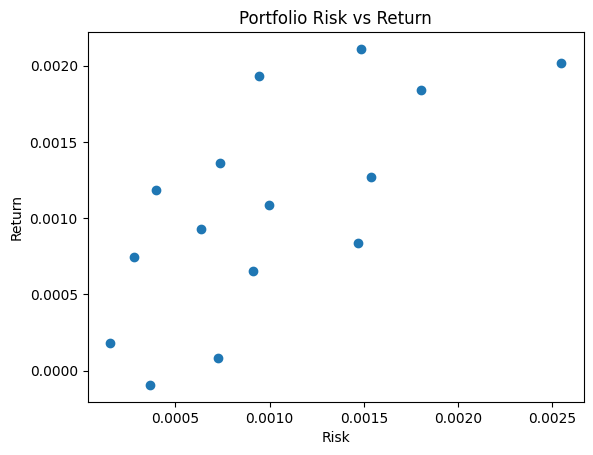

In [18]:
plt.scatter(
    Evaluation_DataFrame["Portfolio_Risk"],
    Evaluation_DataFrame["Portfolio_Return"]
)

plt.xlabel("Risk")
plt.ylabel("Return")
plt.title("Portfolio Risk vs Return")
plt.show()